In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv("../export/paraminumet.csv")

In [47]:
print(f"SHAPE : {df.shape}")
print(f"COLUMNS : {df.columns.tolist()}")

SHAPE : (697581, 7)
COLUMNS : ['param_id', 'location_id', 'fecha_inicio', 'fecha_fin', 'value', 'code', 'granularidad']


In [48]:
# solo una granularidad
df["granularidad"].unique().tolist()

['HORA']

In [49]:
# codes?
df["code"].unique().tolist()

['PRECIP_HORARIA', 'HUM_RELATIVA']

In [ ]:
df["fecha_fin"].isna().sum()

In [50]:
df = df.drop(columns=["param_id", "fecha_fin", "granularidad"])
df.head()

,location_id,fecha_inicio,value,code
0,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,2022-12-16 11:00:00,0.0,PRECIP_HORARIA
1,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,2022-12-16 12:00:00,0.0,PRECIP_HORARIA
2,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,2022-12-16 13:00:00,0.0,PRECIP_HORARIA
3,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,2022-12-16 14:00:00,0.0,PRECIP_HORARIA
4,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,2022-12-16 15:00:00,0.0,PRECIP_HORARIA


In [ ]:
df = df.rename(columns={"fecha_inicio": "fecha"}) # solo fecha pa que inicio
df["fecha"] = pd.to_datetime(df["fecha"]) # de string a datetime
df = df.set_index("fecha").sort_index() # fecha como index y ordenar

In [52]:
df.head()

,location_id,value,code
fecha,,,
2020-01-01 00:00:00,fca40b66-3095-bb02-f981-15365abf3389,96.0,HUM_RELATIVA
2020-01-01 00:00:00,5a8bb75e-c599-6c54-459e-c48211b11936,0.2,PRECIP_HORARIA
2020-01-01 00:00:00,78a8b0f9-885d-db62-30cd-67ec7db057ed,82.0,HUM_RELATIVA
2020-01-01 00:00:00,e3c05c73-e1e7-3cb0-0e70-cadb7c97ecdb,76.0,HUM_RELATIVA
2020-01-01 01:00:00,5a8bb75e-c599-6c54-459e-c48211b11936,0.0,PRECIP_HORARIA


#### Periodo de tiempo

In [54]:
df.index.min(), df.index.max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2026-06-10 04:00:00'))

In [55]:
df_prec = df[df["code"] == "PRECIP_HORARIA"]
df_hum = df[df["code"] == "HUMEDAD_RELATIVA"]

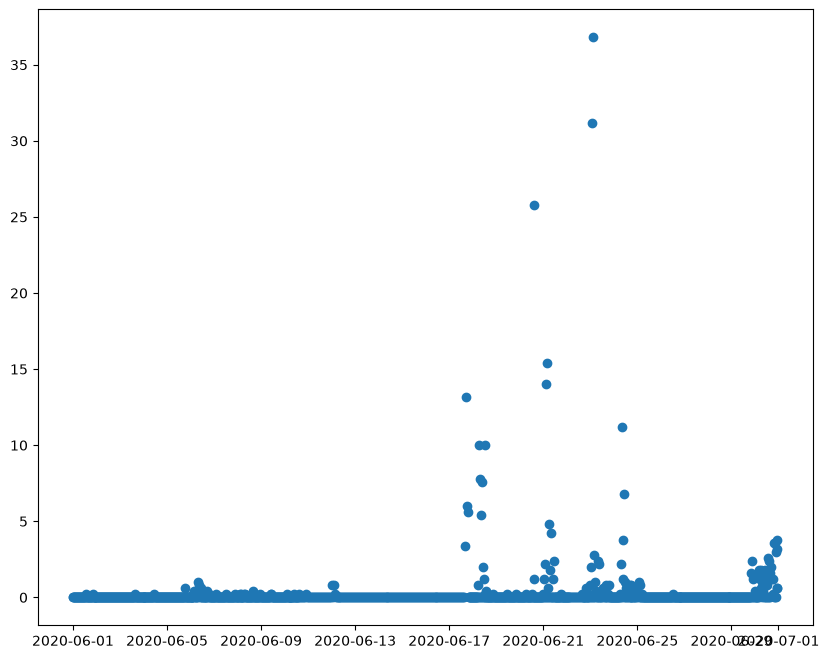

In [66]:
plt.figure(figsize=(10, 8))
plt.scatter(df_prec.loc["2020-06"].index, df_prec.loc["2020-06"]["value"])
plt.show()